# 第九章：主成分分析 (Principal Component Analysis, PCA)

## 9.1 PCA：在保留信息的前提下降低维度

### 为什么要降维

64 维的手写数字数据在存储和计算上不算负担。但真实场景中，基因表达数据可能上万维，文本的 TF-IDF 特征可能百万维。高维数据有两个问题：计算开销大（距离计算、模型训练的复杂度随维度增长），以及**维度灾难**——高维空间中所有点之间的距离趋于相等，基于距离的方法（KNN、聚类）失效。

降维的目标：把数据从 $d$ 维压缩到 $k$ 维（$k < d$），尽量保留原始数据的"结构"。PCA 选择保留的结构是**方差**——方差越大的方向包含的信息越多。

### PCA 的几何直觉

假设数据在二维空间中呈椭圆形分布，长轴方向方差大（数据沿这个方向分散），短轴方向方差小。PCA 找到长轴方向（第一主成分），将数据投影到该方向上，从二维压缩到一维。

这个投影不是随意选的——PCA 选择使投影后方差最大的方向。公式化：

$$\max_{\|\mathbf{w}\|=1} \text{Var}(\mathbf{w}^T \mathbf{X}) = \max_{\|\mathbf{w}\|=1} \mathbf{w}^T \mathbf{C} \mathbf{w}$$

其中 $\mathbf{C} = \frac{1}{n-1} \mathbf{X}^T \mathbf{X}$ 是数据的协方差矩阵。这是一个约束优化问题——在 $\mathbf{w}$ 是单位向量的条件下最大化投影方差。拉格朗日乘子法求解：

$$\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^T \mathbf{C} \mathbf{w} - \lambda(\mathbf{w}^T \mathbf{w} - 1)$$

令梯度为零：$2\mathbf{C}\mathbf{w} - 2\lambda\mathbf{w} = 0$，即 $\mathbf{C}\mathbf{w} = \lambda\mathbf{w}$。

这意味着 $\mathbf{w}$ 必须是 $\mathbf{C}$ 的**特征向量**，对应的**特征值 $\lambda$** 恰好等于投影方差 $\mathbf{w}^T \mathbf{C} \mathbf{w}$。因此：

- 第一主成分 = 最大特征值对应的特征向量（方差最大方向）
- 第二主成分 = 第二大特征值对应的特征向量（与第一正交的方差最大方向）
- 第 $k$ 主成分 = 第 $k$ 大特征值对应的特征向量

PCA 将降维问题转化为协方差矩阵的**特征分解**——不需要迭代优化，直接求解特征值/特征向量即可。保留的方差比例 = $\sum_{i=1}^k \lambda_i / \sum_{i=1}^d \lambda_i$。


### PCA 的最优化视角：Rayleigh 商与特征值问题

前面从"最大方差"角度描述了 PCA，这里给出严格的数学推导。

**问题表述**：寻找投影方向 $\mathbf{w}$（$\|\mathbf{w}\| = 1$），使得数据投影后的方差最大化。

数据 $\mathbf{X}$ 已中心化。投影后，样本 $\mathbf{x}_i$ 在 $\mathbf{w}$ 方向上的坐标为 $\mathbf{w}^T \mathbf{x}_i$。投影方差为：

$$\frac{1}{n-1} \sum_{i=1}^n (\mathbf{w}^T \mathbf{x}_i)^2 = \frac{1}{n-1} \mathbf{w}^T \mathbf{X}^T \mathbf{X} \mathbf{w} = \mathbf{w}^T \mathbf{C} \mathbf{w}$$

其中 $\mathbf{C} = \frac{1}{n-1} \mathbf{X}^T \mathbf{X}$ 是协方差矩阵。优化问题为：

$$\max_{\|\mathbf{w}\|=1} \mathbf{w}^T \mathbf{C} \mathbf{w}$$

**Rayleigh 商** $R(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{C} \mathbf{w}}{\mathbf{w}^T \mathbf{w}}$。由于 $\|\mathbf{w}\|=1$，分母为 1，$R(\mathbf{w}) = \mathbf{w}^T \mathbf{C} \mathbf{w}$。

**关键性质**：Rayleigh 商在 $\mathbf{C}$ 的最大特征值对应的特征向量处取得最大值，最大值为该特征值。

**拉格朗日乘子法证明**：

拉格朗日函数：$\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^T \mathbf{C} \mathbf{w} - \lambda (\mathbf{w}^T \mathbf{w} - 1)$

令梯度为 0：

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 2\mathbf{C}\mathbf{w} - 2\lambda \mathbf{w} = 0 \quad \Rightarrow \quad \mathbf{C}\mathbf{w} = \lambda \mathbf{w}$$

这正是特征值方程。$\mathbf{w}$ 是 $\mathbf{C}$ 的特征向量，对应的特征值 $\lambda = \mathbf{w}^T \mathbf{C} \mathbf{w}$ 就是投影方差。因此：

- **第一主成分** = 最大特征值对应的特征向量
- **第 $k$ 主成分** = 第 $k$ 大特征值对应的特征向量（与前 $k-1$ 个正交）
- **方差解释率** = $\lambda_k / \sum_i \lambda_i$

> PCA 不是"数学技巧"——它是协方差矩阵的谱分解。主成分 = 特征向量，方差 = 特征值。理解了这个，PCA 就从"降维方法"升格为"数据协方差结构的完整描述"。


### PCA (Principal Component Analysis) 的三种等价视角

同一个 PCA 可以从三个完全不同的角度推导出来——说明它抓住的是数据本质：

1. **最大方差**：$\max_{\|w\|=1} w^TCw$ → 最大特征值对应的特征向量
2. **最小重建误差**：$\min \|X - XWW^T\|_F^2 → ^TX $ 的前 k 个特征向量
3. **最大互信息**：高斯分布下三者严格等价

协方差矩阵对称半正定 → 特征值全为实数、特征向量正交。Rayleigh 商定理保证 $\lambda_{max} = w^TCw$ 的最大值。


## 9.2 PCA 的数学推导

### Step 1: 数据中心化

$$\bar{\mathbf{x}} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{x}_i, \quad \tilde{\mathbf{x}}_i = \mathbf{x}_i - \bar{\mathbf{x}}$$

矩阵形式：$\tilde{\mathbf{X}} = \mathbf{X} - \mathbf{1}_n \bar{\mathbf{x}}^T$。中心化消除数据整体偏移对协方差计算的影响。

### Step 2: 协方差矩阵

$$\mathbf{C} = \frac{1}{n-1} \tilde{\mathbf{X}}^T \tilde{\mathbf{X}}$$

$(\tilde{\mathbf{X}}^T \tilde{\mathbf{X}})_{ij} = \sum_k \tilde{x}_{ki} \tilde{x}_{kj}$，除以 $n-1$ 后：对角线是各特征的方差，非对角线是特征间的协方差。

### Step 3: 优化问题的构造

目标：在约束下最大化投影方差。投影方向 $\mathbf{w}$ 必须是单位向量：

$$\max_{\mathbf{w}} \; \mathbf{w}^T \mathbf{C} \mathbf{w} \quad \text{s.t.} \quad \mathbf{w}^T \mathbf{w} = 1$$

$\mathbf{w}^T \mathbf{C} \mathbf{w}$ 是投影方差。约束 $\mathbf{w}^T \mathbf{w} = 1$ 防止 $\mathbf{w}$ 无限放大。

### Step 4: 拉格朗日乘子法

对于"最大化 $f(\mathbf{w})$，满足 $g(\mathbf{w}) = 0$"，构造规则：

$$\mathcal{L}(\mathbf{w}, \lambda) = f(\mathbf{w}) - \lambda \cdot g(\mathbf{w})$$

应用到 PCA：$f(\mathbf{w}) = \mathbf{w}^T \mathbf{C} \mathbf{w}$，$g(\mathbf{w}) = \mathbf{w}^T \mathbf{w} - 1$：

$$\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^T \mathbf{C} \mathbf{w} - \lambda(\mathbf{w}^T \mathbf{w} - 1)$$

### Step 5: 求解

对 $\mathbf{w}$ 求梯度。$\frac{\partial}{\partial \mathbf{w}}[\mathbf{w}^T \mathbf{C} \mathbf{w}] = 2\mathbf{C}\mathbf{w}$，$\frac{\partial}{\partial \mathbf{w}}[\mathbf{w}^T \mathbf{w}] = 2\mathbf{w}$。令梯度为零：

$$2\mathbf{C}\mathbf{w} - 2\lambda \mathbf{w} = 0 \quad \Rightarrow \quad \mathbf{C}\mathbf{w} = \lambda \mathbf{w}$$

这就是特征方程。$\mathbf{w}$ 必须是 $\mathbf{C}$ 的特征向量。代入目标：$\mathbf{w}^T \mathbf{C} \mathbf{w} = \mathbf{w}^T (\lambda \mathbf{w}) = \lambda$。特征值就是投影方差。最大特征值对应第一主成分。

### Step 6: 降维与重建

取前 $k$ 个特征向量组成投影矩阵 $\mathbf{W}_k = [\mathbf{v}_1, \ldots, \mathbf{v}_k] \in \mathbb{R}^{d \times k}$。

降维：$\mathbf{Z} = \tilde{\mathbf{X}} \mathbf{W}_k$（$n \times d \to n \times k$）

重建：$\hat{\mathbf{X}} = \mathbf{Z} \mathbf{W}_k^T + \bar{\mathbf{x}}$。对单个样本：$\hat{\mathbf{x}}_i = \sum_{j=1}^{k} z_{ij} \mathbf{v}_j + \bar{\mathbf{x}}$——用 $k$ 个主成分向量的加权和近似原始样本。

原始样本可分解为：$\tilde{\mathbf{x}} = \tilde{\mathbf{x}} \mathbf{W}_k \mathbf{W}_k^T$（保留）+ $\tilde{\mathbf{x}} (\mathbf{I} - \mathbf{W}_k \mathbf{W}_k^T)$（丢弃，永久丢失）

### Step 7: 方差解释率

$$\text{保留比例} = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

取满足累积方差 $\ge 95\%$ 的最小 $k$。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_iris, make_blobs
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# === PCA 从零实现 ===
class PCA:
    """主成分分析 — 基于特征值分解的手工实现"""
    
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None      # 主成分方向 (k × d)
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None
    
    def fit(self, X):
        """
        X: (n_samples, n_features)
        
        步骤:
        1. 中心化
        2. 计算协方差矩阵
        3. 特征值分解
        4. 选择前 k 个主成分
        """
        n, d = X.shape
        
        # Step 1: 中心化
        self.mean_ = X.mean(axis=0)  # 沿指定维度求均值
        X_centered = X - self.mean_
        
        # Step 2: 协方差矩阵 C = (1/(n-1)) X^T X
        C = (X_centered.T @ X_centered) / (n - 1)
        
        # Step 3: 特征值分解
        eigenvalues, eigenvectors = np.linalg.eigh(C)  # 对称矩阵的特征值分解
        
        # eigh 返回升序，反转为降序
        idx = np.argsort(eigenvalues)[::-1]  # 返回排序后的索引
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        # Step 4: 选择前 k 个主成分
        k = self.n_components if self.n_components else d
        self.components_ = eigenvectors[:, :k].T  # (k, d)
        self.explained_variance_ = eigenvalues[:k]
        self.explained_variance_ratio_ = eigenvalues[:k] / eigenvalues.sum()  # 沿指定维度求和
        
        return self  # 返回结果
    
    def transform(self, X):
        """降维: Z = (X - mean) @ W^T"""
        X_centered = X - self.mean_
        return X_centered @ self.components_.T  # 返回结果
    
    def inverse_transform(self, Z):
        """重建: X_recon = Z @ W + mean"""
        return Z @ self.components_ + self.mean_  # 返回结果

# === 测试：二维数据降维到一维 ===
np.random.seed(42)  # 固定随机种子，保证结果可复现
# 生成有相关性的二维数据
mean = [3, 7]
cov = [[2.0, 1.5], [1.5, 1.0]]  # 正相关
X_test = np.random.multivariate_normal(mean, cov, 200)

pca = PCA(n_components=2)
pca.fit(X_test)  # 训练模型（拟合数据）

print("=" * 50)
print("PCA 结果分析")
print("=" * 50)
print(f"特征值: {pca.explained_variance_}")
print(f"方差解释率: {pca.explained_variance_ratio_}")
print(f"累积解释率: {pca.explained_variance_ratio_.cumsum()}")
print(f"\n第一主成分方向: {pca.components_[0]}")
print(f"第二主成分方向: {pca.components_[1]}")
print(f"两主成分正交: {np.dot(pca.components_[0], pca.components_[1]):.10f}")  # 向量点积


PCA 结果分析
特征值: [2.8266395  0.07548616]
方差解释率: [0.97398936 0.02601064]
累积解释率: [0.97398936 1.        ]

第一主成分方向: [-0.81400456 -0.58085848]
第二主成分方向: [ 0.58085848 -0.81400456]
两主成分正交: 0.0000000000


/tmp/ipykernel_20678/639902460.py:69: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_test = np.random.multivariate_normal(mean, cov, 200)


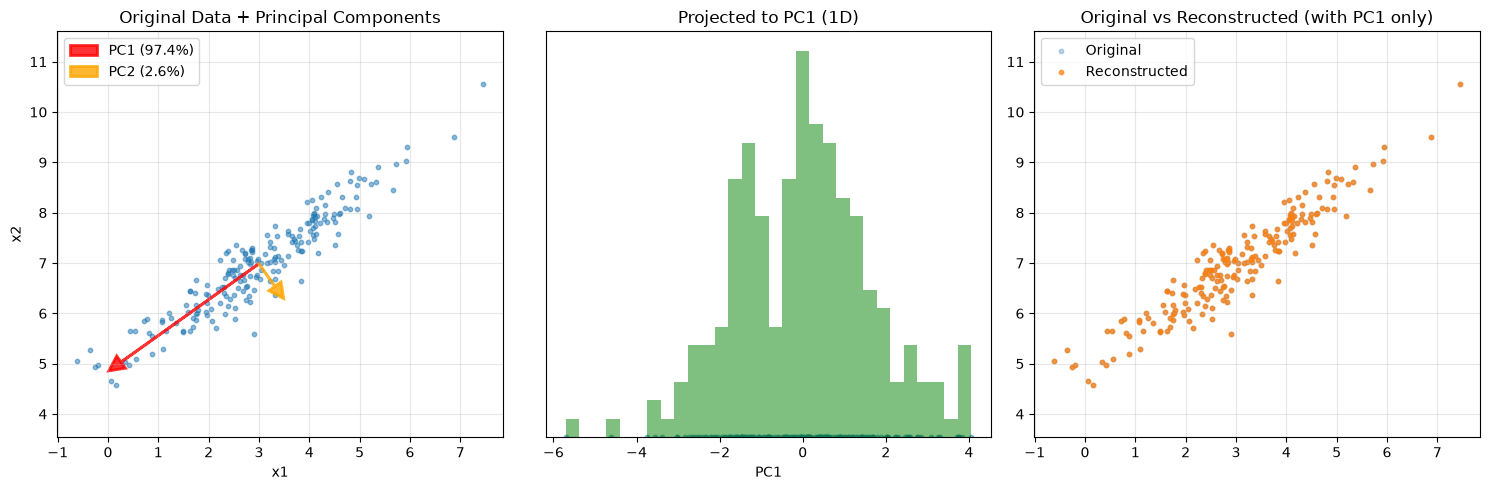


仅用 PC1 重建的均方误差: 0.0000
PC1 损失的信息比例: 2.60%


In [2]:
# === PCA 降维可视化 ===
import numpy as np
import matplotlib.pyplot as plt
X_proj = pca.transform(X_test)  # 对数据应用变换
X_recon = pca.inverse_transform(X_proj)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 创建子图网格

# 原始数据 + 主成分方向
ax = axes[0]
ax.scatter(X_test[:, 0], X_test[:, 1], alpha=0.5, s=10)
origin = pca.mean_
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    # 箭头长度 = 2 * sqrt(特征值)（2 个标准差）
    length = 2 * np.sqrt(var)  # 平方根
    ax.arrow(origin[0], origin[1],
             comp[0] * length, comp[1] * length,
             head_width=0.3, head_length=0.3,
             fc=['red', 'orange'][i], ec=['red', 'orange'][i],
             alpha=0.8, linewidth=2,
             label=f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
ax.set_title('Original Data + Principal Components')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.legend(); ax.grid(True, alpha=0.3); ax.axis('equal')

# 降维后的一维分布
ax = axes[1]
ax.scatter(X_proj[:, 0], np.zeros_like(X_proj[:, 0]), alpha=0.5, s=10)
ax.hist(X_proj[:, 0], bins=30, alpha=0.5, density=True, color='green')
ax.set_title('Projected to PC1 (1D)')
ax.set_xlabel('PC1'); ax.set_yticks([])

# 重建 vs 原始
ax = axes[2]
ax.scatter(X_test[:, 0], X_test[:, 1], alpha=0.3, s=10, label='Original')
ax.scatter(X_recon[:, 0], X_recon[:, 1], alpha=0.7, s=10, label='Reconstructed')
# 连几条线展示投影方向
for i in range(20):
    ax.plot([X_test[i, 0], X_recon[i, 0]],
            [X_test[i, 1], X_recon[i, 1]], 'gray', alpha=0.3, lw=0.5)
ax.set_title('Original vs Reconstructed (with PC1 only)')
ax.legend(); ax.grid(True, alpha=0.3); ax.axis('equal')

plt.tight_layout()  # 自动调整子图间距
plt.savefig('../fig/pca_2d_demo.png', dpi=100, bbox_inches='tight')  # 保存图片到文件
plt.show()  # 显示图表

# 重建误差
recon_error = np.mean((X_test - X_recon) ** 2)  # 计算均值
print(f"\n仅用 PC1 重建的均方误差: {recon_error:.4f}")
print(f"PC1 损失的信息比例: {1 - pca.explained_variance_ratio_[0]:.2%}")


## 9.3 PCA (Principal Component Analysis) 在高维数据上的应用

### 手写数字 (Digits) 降维

Digits 数据集：8×8 灰度手写数字图片（64 维）。我们用它演示 PCA 降维和重建。


数据形状: (1797, 64)
值范围: [0.0, 16.0]


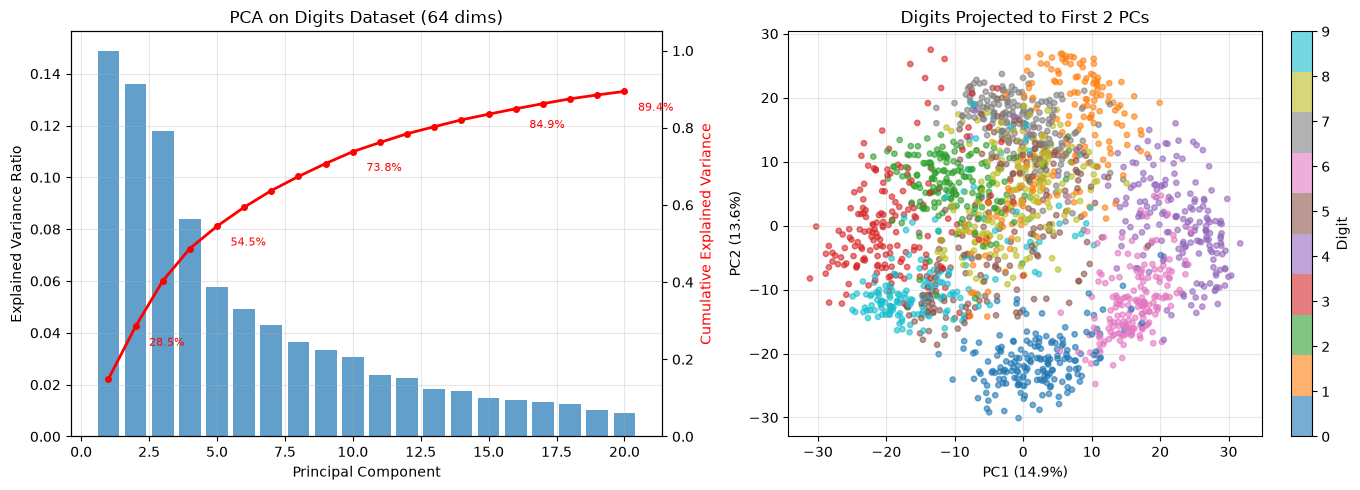

前 2 个 PC 解释的方差: 28.51%
前 10 个 PC 解释的方差: 73.82%
前 16 个 PC 解释的方差: 84.94%


In [3]:
# === Digits 数据集 PCA ===
import matplotlib.pyplot as plt
digits = load_digits()
X_digits = digits.data      # (1797, 64)
y_digits = digits.target

print(f"数据形状: {X_digits.shape}")
print(f"值范围: [{X_digits.min():.1f}, {X_digits.max():.1f}]")  # 沿指定维度取最大值

# PCA 降维
pca_digits = PCA()
pca_digits.fit(X_digits)  # 训练模型（拟合数据）

# 方差解释曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 创建子图网格

ax = axes[0]
ax.bar(range(1, 21), pca_digits.explained_variance_ratio_[:20], alpha=0.7)
cumsum = pca_digits.explained_variance_ratio_.cumsum()
ax2 = ax.twinx()
ax2.plot(range(1, 21), cumsum[:20], 'ro-', markersize=4, linewidth=2)
ax2.set_ylabel('Cumulative Explained Variance', color='red')
ax2.set_ylim(0, 1.05)

# 标注关键累积值
for k in [2, 5, 10, 16, 20]:
    ax2.annotate(f'{cumsum[k-1]:.1%}',
                xy=(k, cumsum[k-1]),
                xytext=(k+0.5, cumsum[k-1]-0.05),
                fontsize=8, color='red')

ax.set_xlabel('Principal Component'); ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA on Digits Dataset (64 dims)')
ax.grid(True, alpha=0.3)

# 2D 投影可视化
ax = axes[1]
Z = pca_digits.transform(X_digits)  # 对数据应用变换
scatter = ax.scatter(Z[:, 0], Z[:, 1], c=y_digits, cmap='tab10',
                     alpha=0.6, s=15)
ax.set_xlabel(f'PC1 ({pca_digits.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_digits.explained_variance_ratio_[1]:.1%})')
ax.set_title('Digits Projected to First 2 PCs')
plt.colorbar(scatter, ax=ax, label='Digit')  # 颜色条
ax.grid(True, alpha=0.3)

plt.tight_layout()  # 自动调整子图间距
plt.savefig('../fig/pca_digits.png', dpi=100, bbox_inches='tight')  # 保存图片到文件
plt.show()  # 显示图表

print(f"前 2 个 PC 解释的方差: {cumsum[1]:.2%}")
print(f"前 10 个 PC 解释的方差: {cumsum[9]:.2%}")
print(f"前 16 个 PC 解释的方差: {cumsum[15]:.2%}")


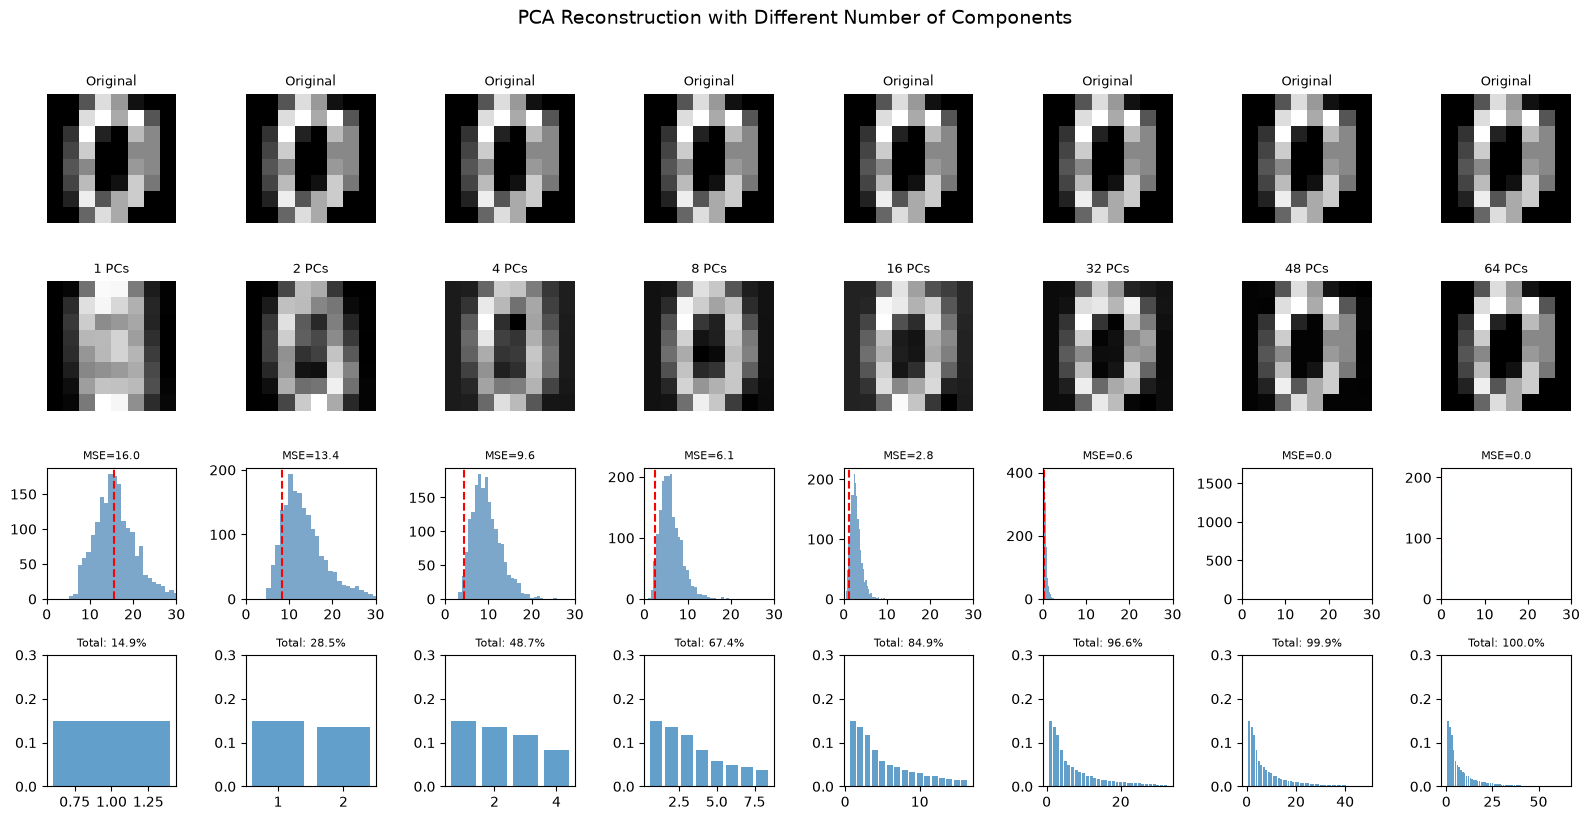

In [4]:
# === 用不同数量主成分重建图像 ===
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 8, figsize=(16, 8))  # 创建子图网格
n_components_list = [1, 2, 4, 8, 16, 32, 48, 64]
sample_idx = 0  # 第一个数字

for i, n_comp in enumerate(n_components_list):
    # 用 n_comp 个 PC 重建
    pca_temp = PCA(n_components=n_comp)
    pca_temp.fit(X_digits)  # 训练模型（拟合数据）
    Z = pca_temp.transform(X_digits)  # 对数据应用变换
    X_recon = pca_temp.inverse_transform(Z)
    
    # 原始图像
    axes[0, i].imshow(X_digits[sample_idx].reshape(8, 8), cmap='gray')  # 改变张量形状
    axes[0, i].set_title(f'Original', fontsize=9)
    axes[0, i].axis('off')
    
    # 重建图像
    axes[1, i].imshow(X_recon[sample_idx].reshape(8, 8), cmap='gray')  # 改变张量形状
    axes[1, i].set_title(f'{n_comp} PCs', fontsize=9)
    axes[1, i].axis('off')
    
    # 重建误差分布
    error = ((X_digits - X_recon) ** 2).mean(axis=1)  # 沿指定维度求均值
    axes[2, i].hist(error, bins=30, alpha=0.7, color='steelblue')
    axes[2, i].axvline(error[sample_idx], color='red', lw=1.5, linestyle='--')
    axes[2, i].set_title(f'MSE={error.mean():.1f}', fontsize=8)  # 沿指定维度求均值
    axes[2, i].set_xlim(0, 30)
    
    # 累积方差解释
    axes[3, i].bar(range(1, n_comp+1), pca_temp.explained_variance_ratio_, alpha=0.7)
    axes[3, i].set_title(f'Total: {pca_temp.explained_variance_ratio_.sum():.1%}', fontsize=8)  # 沿指定维度求和
    axes[3, i].set_ylim(0, 0.3)

plt.suptitle('PCA Reconstruction with Different Number of Components', fontsize=14, y=1.02)
plt.tight_layout()  # 自动调整子图间距
plt.savefig('../fig/pca_reconstruction.png', dpi=100, bbox_inches='tight')  # 保存图片到文件
plt.show()  # 显示图表


### PCA (Principal Component Analysis) 的关键洞察

1. **特征值 = 方差**：$\lambda_i$ 越大，该方向包含的信息越多
2. **正交性**：主成分之间线性无关（$\mathbf{v}_i^T \mathbf{v}_j = 0$），去除了特征间的冗余
3. **线性方法**：PCA 只能捕捉线性关系——如果数据分布在曲面上，PCA 效果有限（此时应考虑 t-SNE、UMAP 等非线性方法）
4. **可解释的降维**：每个主成分是原始特征的线性组合，可以分析哪些特征对该成分贡献最大
5. **数据预处理**：PCA 对特征尺度敏感——不同量纲的特征应先标准化（$z = (x-\mu)/\sigma$）


> **下一章**：PCA 只能捕捉线性结构。第十章将讲解非线性降维方法（t-SNE/UMAP）以及生成模型（VAE (Variational Autoencoder)/DDcGAN），它们能发现 PCA 看不到的复杂模式。